In [24]:
import numpy as np 
from scipy.integrate import solve_ivp
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset
import torch.nn.functional as F  
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 

In [32]:
###
# Helper functions for "infinite width" neural network 
### 

# Approximates the expected value of activation(f_i)activation(f_j) for f sampled from a Gaussian distribution with 
# covariance matrix sigma. 
# Does this by averaging the specified number of samples 
def approx_expec(sigma, activation, num_samples=40):
	samples = activation(np.random.multivariate_normal(np.zeros(sigma.shape[0]), sigma, num_samples))
	return np.einsum('ij,ik',samples, samples) / num_samples 

# Gets the covariance matrices for a two layer, "infinite width" neural network 
# activation should be vectorized 
def get_sigmas(x, beta, activation, num_samples = 40):
	# Build the covariance matrix for the first layer 
	sigma_1 = np.outer(x, x) + beta*beta 

	# Estimate the covariance matrix for the second layer 
	sigma_2 = approx_expec(sigma_1, activation, num_samples) + beta*beta

	return sigma_1, sigma_2
			   
# Builds a NTK for one-dimensional input and output data 
# 
# sigma_1 and sigma_2 are the covariance matrices for the first two layers 
# activation_prime is the derivative of the activation function. It should be vectorized. 
# num_samples is the number of samples used to estimate expectations 
# Returns an array K such that K[i,j] is the NTK evaluated at (x[i], x[j])
def get_ntk(x, activation_prime, sigma_1, sigma_2, num_samples=40): 
	# Estimate the "prime" covariance matrix 
	sigma_prime = approx_expec(sigma_1, activation_prime, num_samples)

	return np.multiply(sigma_1, sigma_prime) + sigma_2

In [67]:
### 
# Helper classes for finite width neural networks 
###

# A class to represent a fully connected neural network with one hidden layer 
class OneMLP(nn.Module):
	# Constructor 
	def __init__(self, activation, hidden_size, beta):
		super(OneMLP, self).__init__() 
	
		# Initialize variables 
		self.sqrt_hidden = math.sqrt(hidden_size)
		self.beta = beta 
		self.lin1 = nn.Linear(1, hidden_size, bias = False) 
		self.b1 = torch.normal(0.0, 1.0, size=(1, int(hidden_size)))
		self.activate = activation 
		self.lin2 = nn.Linear(hidden_size, 1, bias = False) 
		self.b2 = torch.normal(0.0, 1.0, size=(1, 1))

		# Initialize the weights to be normal instead of uniform 
		nn.init.normal_(self.lin1.weight)
		nn.init.normal_(self.lin2.weight)

	# Applies the MLP to some input 
	def forward(self, x): 
		a = self.activate(self.lin1(x) + self.beta * self.b1.expand(x.size(0), -1) )

		return self.lin2(a) / self.sqrt_hidden + self.beta * self.b2.expand(x.size(0), -1)

# Represents a basic dataset of the form (X, y). Can be used in conjunction
# with PyTorch's DataLoader 
class BasicDataset(Dataset):
	def __init__(self, x, y):
		self.x = torch.tensor(x, dtype = torch.float).view(len(x), 1)
		self.y = torch.tensor(y, dtype = torch.float).view(len(y), 1) 
	
	def __len__(self):
		return len(self.y)
	
	def __getitem__(self, i):
		return self.x[i, :], self.y[i, :]



In [51]:
# Runs gradient descent on the provided model and data. Returns the test 
# and train loss and accuracy after each epoch. Uses the Adam optimizer. 
# It will print the loss and accuracy every print_freq epochs. 
def run_grad_descent(model, dataset_train, dataset_test, lossfxn, cfg, print_freq = 1, report_acc = True, use_train = True):
	# Put data into a data loader 
	loader_train = DataLoader(dataset_train, shuffle=True, batch_size=cfg['batchSize'])
	loader_test = DataLoader(dataset_test, shuffle=False, batch_size=cfg['batchSize'])
	num_train = len(dataset_train)
	num_test = len(dataset_test) 
	nbr_miniBatch_train = len(loader_train) 
	nbr_miniBatch_test = len(loader_test)

	# Optimizer 
	optimizer = torch.optim.Adam(model.parameters(), lr=cfg['learning_rate'])

	# Record the accuracies and losses 
	train_losses = np.zeros(cfg['numEpoch'])
	train_accuracies = np.zeros(cfg['numEpoch'])
	test_losses = np.zeros(cfg['numEpoch'])
	test_accuracies = np.zeros(cfg['numEpoch'])

	# Gradient descent
	for epoch in range(cfg['numEpoch']):
		if epoch % print_freq == 0:
			print('-- epoch '+str(epoch))  # a new epoch begins

		# Train
		running_loss_train = 0.0
		accuracy_train = 0.0
		if use_train: 
			model.train()
		else:
			model.eval() 
		
		for X_batch,y_batch in loader_train:
		# 1) initialize the gradient " loss" to zero
			optimizer.zero_grad()
			
			# 2) compute the score and loss
			score = model(X_batch)
			loss = lossfxn(score, y_batch)

			# 3) estimate the gradient and update parameters
			loss.backward()
			optimizer.step()
			# 4) estimate the overall loss over the all training set
			running_loss_train += loss.detach().numpy()
			
			if report_acc:
				accuracy_train += (score.argmax(dim=1) == y_batch).sum().numpy()

		# Test
		running_loss_test = 0.0
		accuracy_test = 0.0
		model.eval()
		with torch.no_grad():
			for X_batch,y_batch in loader_test:
				# 1) compute the score and loss
				score = model(X_batch)
				loss = lossfxn(score, y_batch)
				# 2) estimate the overall loss over the all test set
				running_loss_test += loss.detach().numpy()

				if report_acc: 
					accuracy_test += (score.argmax(dim=1) == y_batch).sum().numpy()
		
		# Statistics
		loss_train = running_loss_train/nbr_miniBatch_train
		if nbr_miniBatch_test != 0:
			loss_test = running_loss_test/nbr_miniBatch_test
		else:
			loss_test = 0

		accuracy_train /= num_train
		if num_test != 0:
			accuracy_test /= num_test
		else: 
			accuracy_test = 0

		if epoch % print_freq == 0:
			print('	loss	 (train, test): {:.4f},  {:.4f}'.format(loss_train, loss_test))
			print('	accuracy (train, test): {:.4f},  {:.4f}'.format(accuracy_train, accuracy_test))

		train_losses[epoch] = loss_train
		train_accuracies[epoch] = accuracy_train
		test_losses[epoch] = loss_test
		test_accuracies[epoch] = accuracy_test

	return train_losses, test_losses, train_accuracies, test_accuracies

In [92]:
###
# Initialize variables and generate training data
###
num_grid = 100 
x_vals = np.linspace(0, 2 * np.pi, num_grid)
y_vals = np.sin(x_vals)
beta = 1 
function_label = 'sin(x)'

activation_np = np.tanh
activation_torch = F.tanh 
def activation_prime(x):
	return 1 / np.power(np.cosh(x), 2)

num_train = 10
train_x = np.random.choice(np.arange(num_grid), num_train, True)
train_y = y_vals[train_x]

In [96]:
###
# Solve IVP for our "infinite width" neural network 
### 
num_samples = 40 
t_0 = 0
t_1 = 20000

# Get the covariance matrices 
sigma_1, sigma_2 = get_sigmas(x_vals, beta, activation_np, num_samples) 

# Get f0 
f_0 = np.random.multivariate_normal(np.zeros(sigma_2.shape[0]), sigma_2)

# Get the NTK 
ntk = get_ntk(x_vals, activation_prime, sigma_1, sigma_2, num_samples) 

# The slope function for the IVP 
def slope(t, f): 
	return -np.matmul(ntk[:, train_x], f[train_x] - train_y) / num_train 

# Solve the IVP 
sol = solve_ivp(slope, [t_0, t_1], f_0) 
f = np.array(sol.y[:,-1])

In [94]:
### 
# Train the finite width neural network 
### 

# Initialize variables 
dataset = BasicDataset(x_vals[train_x], train_y) 
test_dataset = BasicDataset([], [])
loss = nn.MSELoss() 
cfg = {'numEpoch':10000, 'learning_rate':1e-3, 'batchSize':16}
hidden_widths = np.arange(5, 50, 10)
init_preds = np.zeros((len(hidden_widths), len(x_vals)))
final_preds = np.zeros((len(hidden_widths), len(x_vals)))

# Try a variety of hidden widths 
for i in range(len(hidden_widths)):
	hidden_width = hidden_widths[i]
	mlp = OneMLP(activation_torch, hidden_width, beta) 

	# Record the initial predictions 
	with torch.no_grad():
		init_preds[i, :] = mlp(torch.tensor(x_vals, dtype=torch.float).view(len(x_vals), 1)).view(len(x_vals))

	# Train 
	run_grad_descent(mlp, dataset, test_dataset, loss, cfg, print_freq = 10000, report_acc = False)

	# Record the post-training prediction 
	with torch.no_grad():
		final_preds[i, :] = mlp(torch.tensor(x_vals, dtype=torch.float).view(len(x_vals), 1)).view(len(x_vals))

-- epoch 0
	loss	 (train, test): 2.7953,  0.0000
	accuracy (train, test): 0.0000,  0.0000
-- epoch 0
	loss	 (train, test): 1.4315,  0.0000
	accuracy (train, test): 0.0000,  0.0000
-- epoch 0
	loss	 (train, test): 2.3399,  0.0000
	accuracy (train, test): 0.0000,  0.0000
-- epoch 0
	loss	 (train, test): 0.5136,  0.0000
	accuracy (train, test): 0.0000,  0.0000
-- epoch 0
	loss	 (train, test): 7.3964,  0.0000
	accuracy (train, test): 0.0000,  0.0000


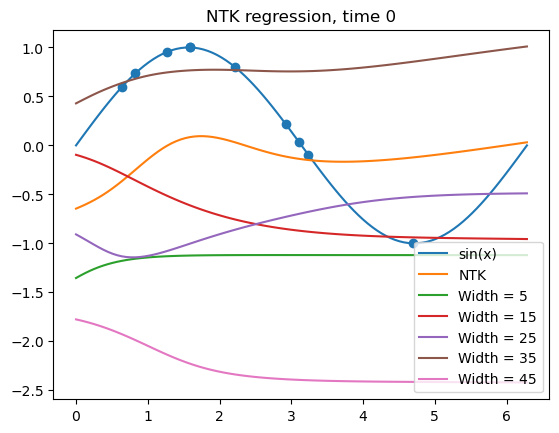

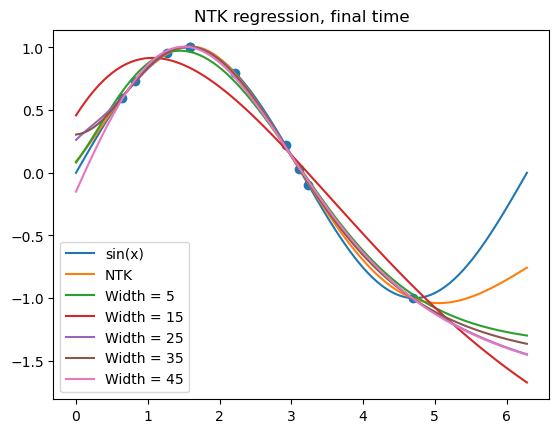

In [97]:
### 
# Plot results 
### 

# Plot initial predictions 
plt.figure()
plt.scatter(x_vals[train_x], train_y)
plt.plot(x_vals, y_vals, label=function_label)
plt.plot(x_vals, f_0, label='NTK')
for i in range(init_preds.shape[0]):
	plt.plot(x_vals, init_preds[i,:], label = 'Width = ' + str(hidden_widths[i]))
plt.legend()
plt.title('NTK regression, time 0')
plt.show()

# Plot final predictions 
plt.figure()
plt.scatter(x_vals[train_x], train_y)
plt.plot(x_vals, y_vals, label=function_label)
plt.plot(x_vals, f, label='NTK') 
for i in range(final_preds.shape[0]):
	plt.plot(x_vals, final_preds[i,:], label = 'Width = ' + str(hidden_widths[i]))
plt.legend()
plt.title('NTK regression, final time')
plt.show()